# EDA - CPI ALIMENTOS (Subproductos)

In [76]:
# Importamos librerías y configuración a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import calendar
def formato_anos(ax, cada_n_anos=2):
    """Formatea eje x para mostrar años de forma limpia"""
    ax.xaxis.set_major_locator(mdates.YearLocator(cada_n_anos))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.style.use("seaborn-v0_8")

# Importamos el dataset limpio
data = pd.read_csv(r"C:\Users\ASUS\Desktop\CFBPredic\src\data.csv")
data = data.set_index("date")

### Análisis de la estructura y calidad de los datos

In [77]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 238 entries, 2006-01-01 to 2025-10-01
Data columns (total 12 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   ipc_alimentos_index                                       238 non-null    float64
 1   aceites_y_grasas                                          238 non-null    float64
 2   aguas_minerales_refrescos_jugos_de_frutas_y_de_legumbres  238 non-null    float64
 3   azucar_mermelada_miel_chocolate_y_dulces_de_azucar        238 non-null    float64
 4   cafe_te_y_cacao                                           238 non-null    float64
 5   carne                                                     238 non-null    float64
 6   frutas                                                    238 non-null    float64
 7   leche_queso_y_huevos                                      238 non-null    float64
 8   legumbres

In [78]:
data.head()

,ipc_alimentos_index,aceites_y_grasas,aguas_minerales_refrescos_jugos_de_frutas_y_de_legumbres,azucar_mermelada_miel_chocolate_y_dulces_de_azucar,cafe_te_y_cacao,carne,frutas,leche_queso_y_huevos,legumbres_hortalizas,pan_y_cereales,pescado,productos_alimenticios_n_e_p
date,,,,,,,,,,,,
2006-01-01,60.91,51.33,62.47,55.45,48.95,61.03,63.57,66.73,72.88,50.38,57.44,60.35
2006-02-01,62.03,50.93,63.41,56.86,48.23,63.90,66.18,66.12,74.62,50.30,58.12,59.94
2006-03-01,63.10,51.28,63.43,58.43,49.08,64.41,69.87,66.05,77.43,50.69,59.30,60.96
2006-04-01,62.45,51.24,62.47,60.56,49.07,62.82,67.99,66.55,75.19,50.32,61.94,61.56
2006-05-01,61.91,51.36,62.40,64.10,49.06,62.92,66.12,67.07,70.09,50.52,63.21,61.78


In [79]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ipc_alimentos_index,238.0,97.411955,16.792485,60.91,85.1675,104.621018,107.280633,122.247946
aceites_y_grasas,238.0,98.426960,21.715033,50.76,88.4050,98.985000,103.397500,157.750030
aguas_minerales_refrescos_jugos_de_frutas_y_de_legumbres,238.0,102.936448,23.263822,62.38,79.2100,107.210000,122.230000,136.625625
azucar_mermelada_miel_chocolate_y_dulces_de_azucar,238.0,95.280065,15.488609,55.45,94.4525,100.530000,102.120000,117.809705
cafe_te_y_cacao,238.0,93.970581,20.999648,47.44,87.5700,100.310000,107.007500,133.672304
carne,238.0,95.273758,14.364234,61.03,85.6775,102.775000,105.265000,114.521719
frutas,238.0,97.118055,16.052649,62.48,87.5575,100.450000,106.950000,140.202043
leche_queso_y_huevos,238.0,96.595282,15.308186,66.05,86.5575,100.715000,103.052500,122.178010
legumbres_hortalizas,238.0,102.531354,16.924838,64.34,92.2350,105.355000,113.147500,137.870000
pan_y_cereales,238.0,94.122458,18.898322,50.30,79.5175,100.040000,105.092500,126.343531


#### La mayoría de productos presentan medias cercanas a 100, lo que refleja que los valores están normalizados respecto al año base
#### Productos que superan el 100 en media como: aguas_minerales_refrescos_jugos_de_futas_y_de_legumbreas, legumbres_hortalizas_productos_alimenticios_n_e_p. Indican que ejercen mayor presión inflacionaria.
#### Rubros como aguas y refrescos, aceites y grasas, café y cacao, pan y cereales, y productos n.e.p muestran una desviación estándar alta, lo que sugiere sensibilidad ante choques externos como variaciones estacionales, cambios en los costos de producción o efectos climáticos que afectan directamente su oferta y demanda. En cambio, productos como carne, azúcar y dulces, leche y huevos exhiben menor variabilidad y precios más estables a lo largo del tiempo.
#### Los valores máximos en categorías como aceites (157.75), productos n.e.p. (147.83) y frutas (140.20) evidencian episodios de inflación puntual fuertes a comparación en categorías más estables como carne o azúcar.


#### Este análisis refleja que la inflación alimentaria no se distribuye uniformemente entre los grupos: los productos frescos, procesados y sensibles a oferta y clima son los principales impulsores de los picos inflacionarios, mientras que otros bienes básicos mantienen un comportamiento más predecible.

# Gráficas

## Evolución el IPC de alimentos a lo largo del tiempo

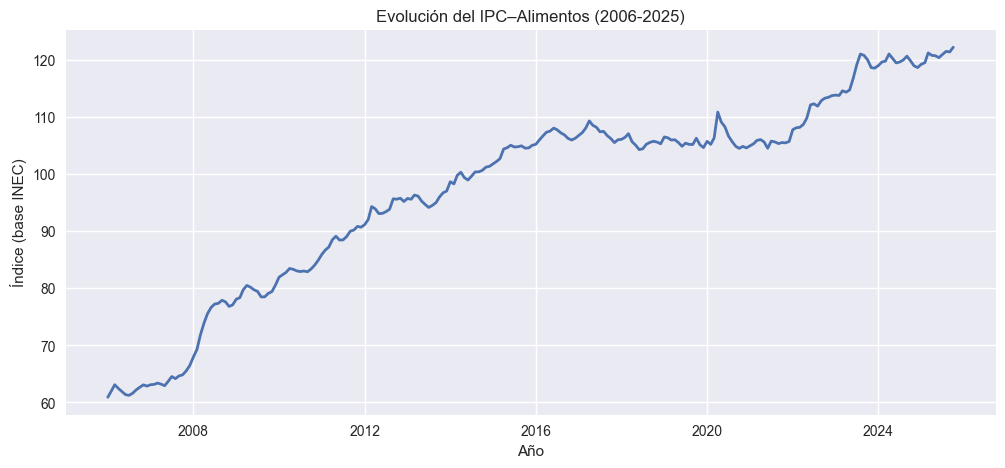

In [91]:
plt.figure(figsize=(12,5))
plt.plot(data.index, data['ipc_alimentos_index'], linewidth=2)
plt.title("Evolución del IPC–Alimentos (2006-2025)")
plt.xlabel("Año")
plt.ylabel("Índice (base INEC)")
plt.grid(True)
formato_anos(ax, cada_n_anos=2)
plt.show()


## Inflación mensual y anual del IPC de alimentos - Variación a lo largo del tiempo

#### Variación mensual del IPC de alimentos:
$$
\%\Delta IPC_t = \frac{IPC_t - IPC_{t-1}}{IPC_{t-1}} \times 100
$$

#### Variación anual (respecto al mismo mes del año anterior)
$$
\%\Delta IPC_{annual} = \frac{IPC_t - IPC_{t-12}}{IPC_{t-12}} \times 100
$$


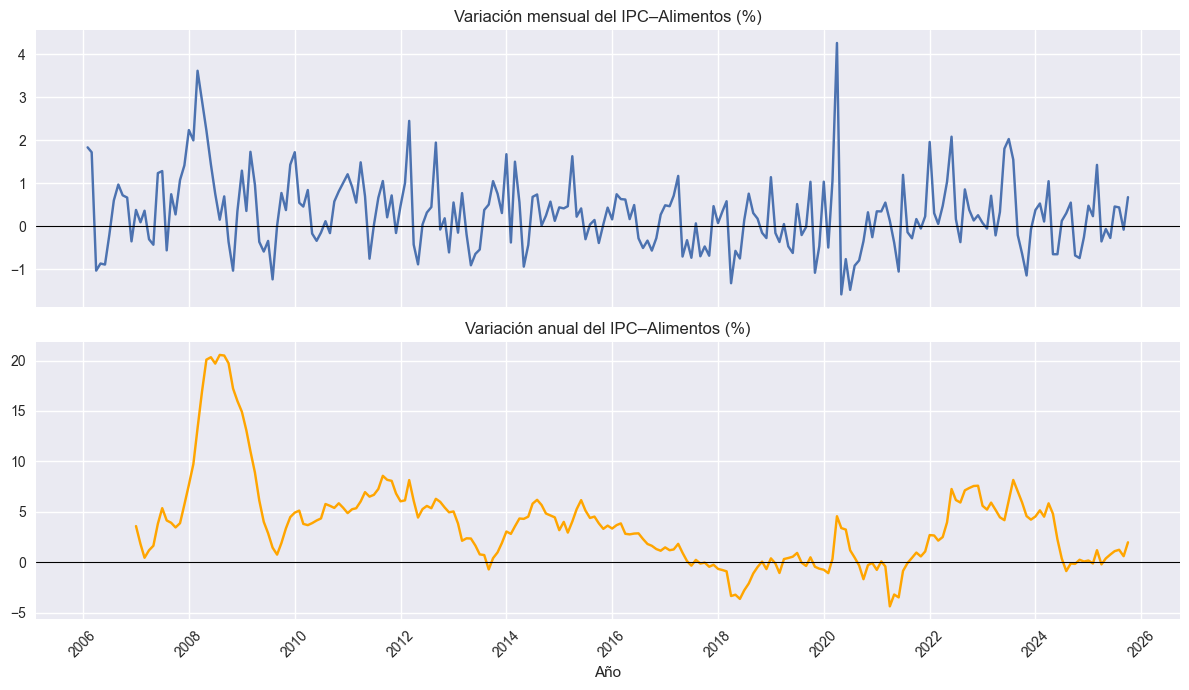

In [98]:
data["ipc_var_mensual"] = data["ipc_alimentos_index"].pct_change() * 100
data["ipc_var_anual"] = data["ipc_alimentos_index"].pct_change(12) * 100

fig, ax = plt.subplots(2, 1, figsize=(12,7), sharex=True)

ax[0].plot(data.index, data["ipc_var_mensual"])
ax[0].set_title("Variación mensual del IPC–Alimentos (%)")
ax[0].axhline(0, color="black", linewidth=0.8)
ax[0].grid(True)

ax[1].plot(data.index, data["ipc_var_anual"], color="orange")
ax[1].set_title("Variación anual del IPC–Alimentos (%)")
ax[1].axhline(0, color="black", linewidth=0.8)
ax[1].grid(True)

plt.xlabel("Año")
formato_anos(ax[1], cada_n_anos=2)
plt.tight_layout()
plt.show()

## IPC de alimentos en tendencia, estacionalidad y ruido usando STL

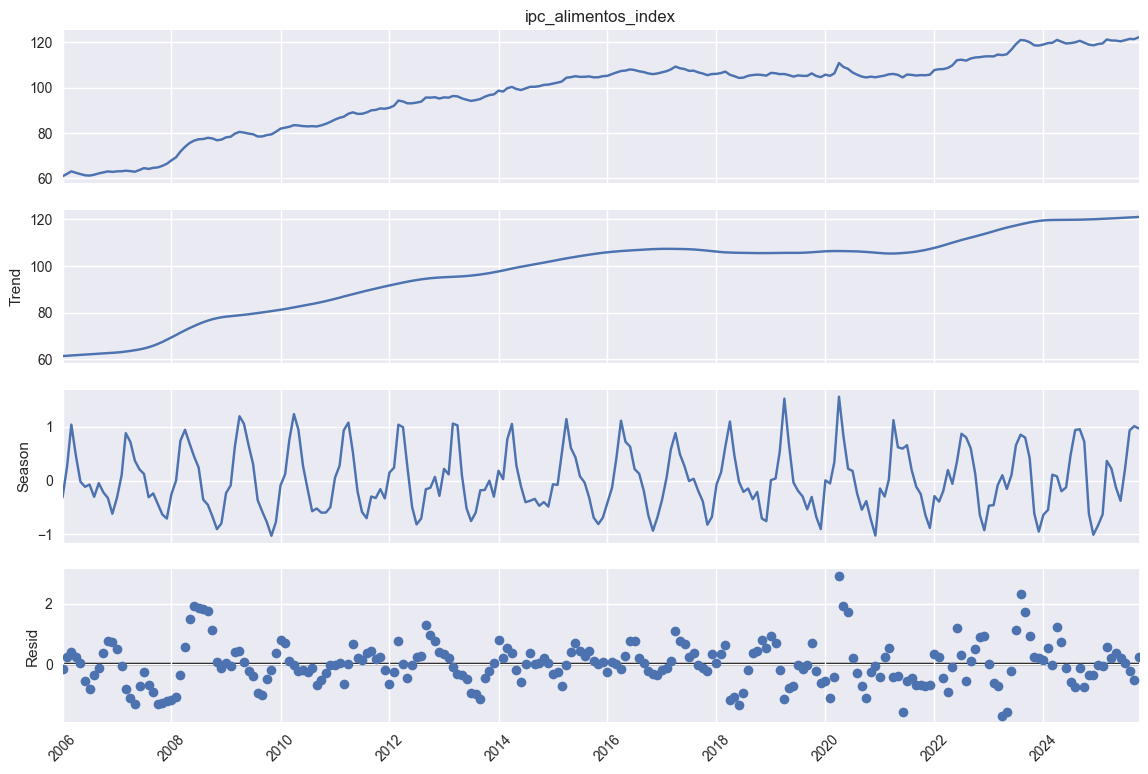

In [93]:
from statsmodels.tsa.seasonal import STL

stl = STL(data['ipc_alimentos_index'], period=12).fit()

fig = stl.plot()
fig.set_size_inches(12,8)
for ax in fig.axes:
    formato_anos(ax, cada_n_anos=2)
plt.show()


#### Se presenta una tendencia a largo plazo creciente, una estacionalidad marcada y estable y un componente residual relativamente pequeño sin patrones sistemáticos.

#### La estacionalidad muestra oscilaciones repetitivas y de amplitud consistente cada 12 meses. Es decir que la inflación de alimentos sigue un ciclo anual predecible. Esto debido a productos que son sensibles a cosechas, precios internacionales y variaciones climáticas.

#### Finalmente, los residuos se distribuyen alrededor de cero sin estructura aparente, lo cual sugiere que el modelo STL logra capturar adecuadamente tanto la forma de la tendencia como la estacionalidad, los valores atípicos que aparecen representan choques puntuales o eventos no explicables por la dinámica histórica normal del mercado.

#### En conjunto, esta descomposición confirma que el comportamiento del IPC de alimentos está dominado por una tendencia alcista estructural y por una fuerte estacionalidad anual.


# Correlación Productos - IPC Alimentos

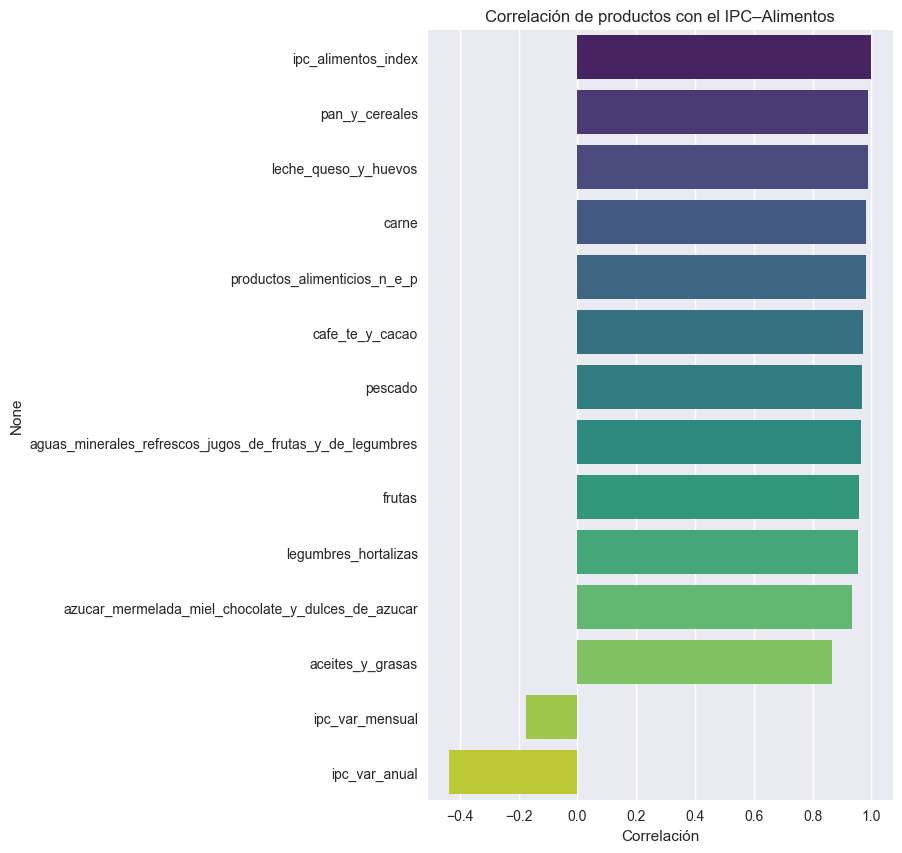

In [83]:
corr = data.corr()['ipc_alimentos_index'].sort_values(ascending=False)
plt.figure(figsize=(6,10))
sns.barplot(
    x=corr.values,
    y=corr.index,
    hue=corr.index,
    palette="viridis",
    dodge=False,
    legend=False
)
plt.title("Correlación de productos con el IPC–Alimentos")
plt.xlabel("Correlación")
plt.show()

#### Casi todos los productos presentan correlaciones positivas y elevadas, siguen la dinámica inflacionaria del conjunto de alimentos.
#### Sus precios tienen a seguir la dirección del índice general.

#### Con una correlación negativa tenemos a los indicadores de variación mensual y anual del IPC. Cuando IPC ya está elevado, sus tasas de cambio tienden a ser más bajas y viceversa. 

#### En conjunto, la inflación alimentaria está impulsada de forma amplia y consistente por casi todos los subgrupos, sin depender de una sola categoría, reflejando una estructura inflacionaria amplia dentro del sector alimentos.

# Mapa de calor - Correlación entre todos los productos e indicadores

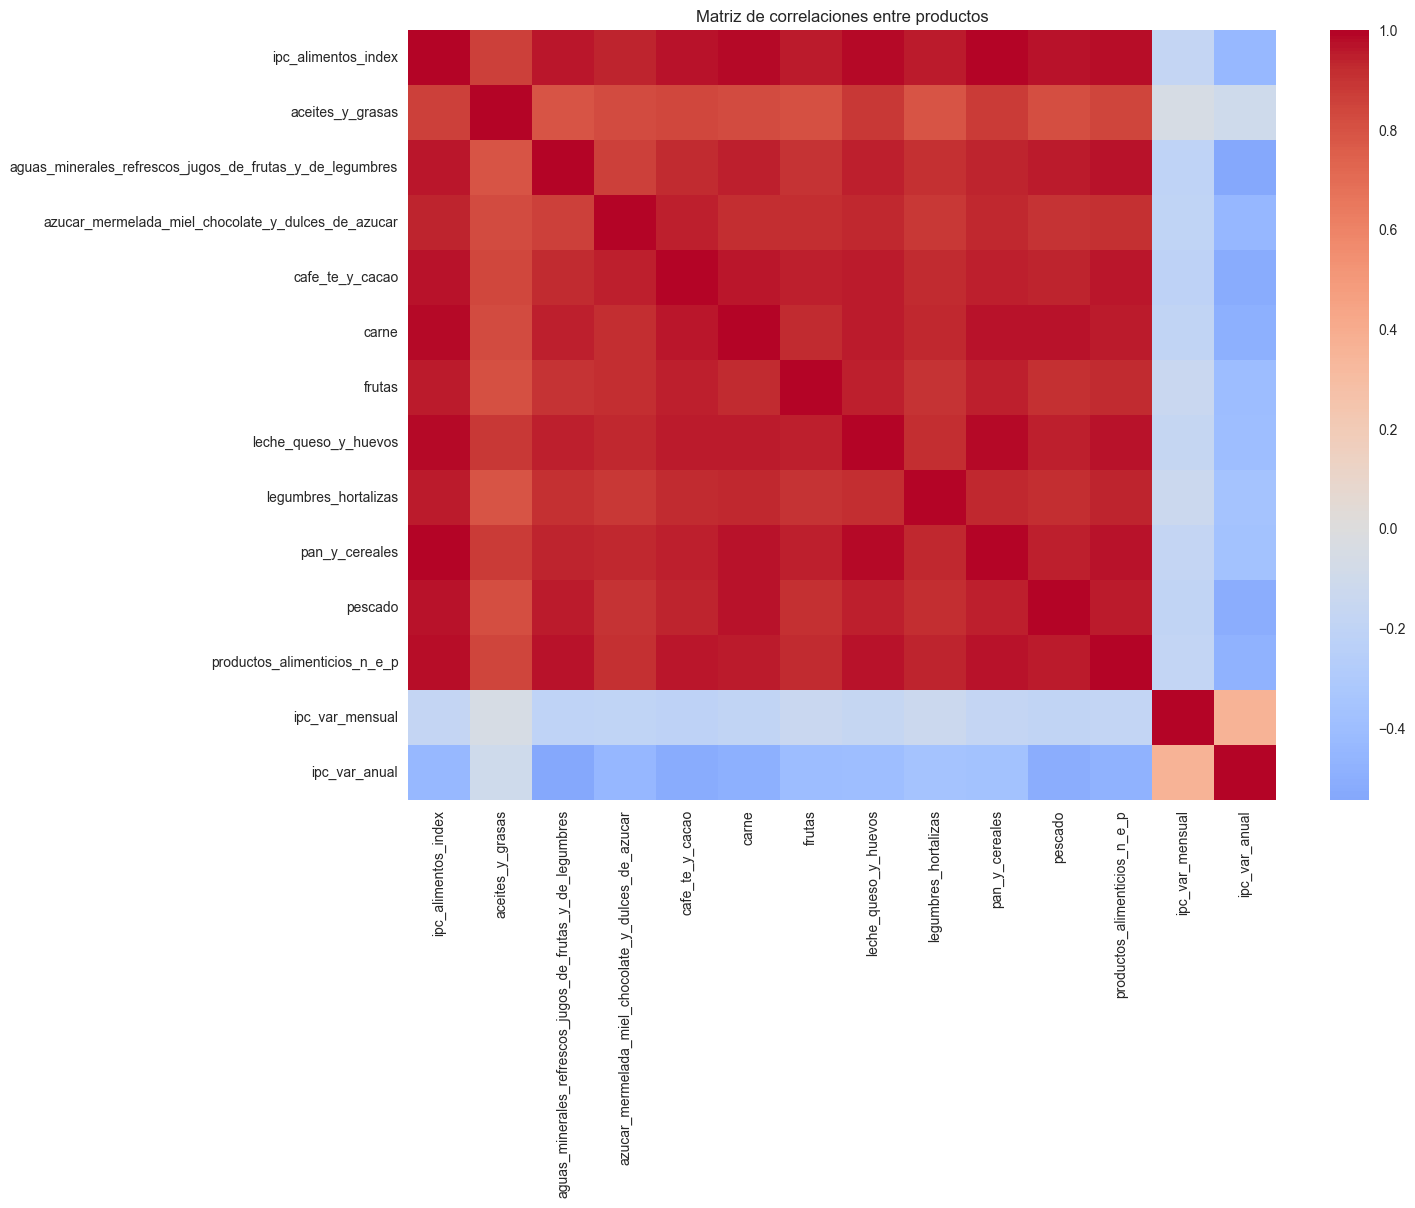

In [84]:
plt.figure(figsize=(14,10))
sns.heatmap(data.corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlaciones entre productos")
plt.show()

# Subplot por cada categoría de producto - Evolución temporal individual dentro del IPC alimentario

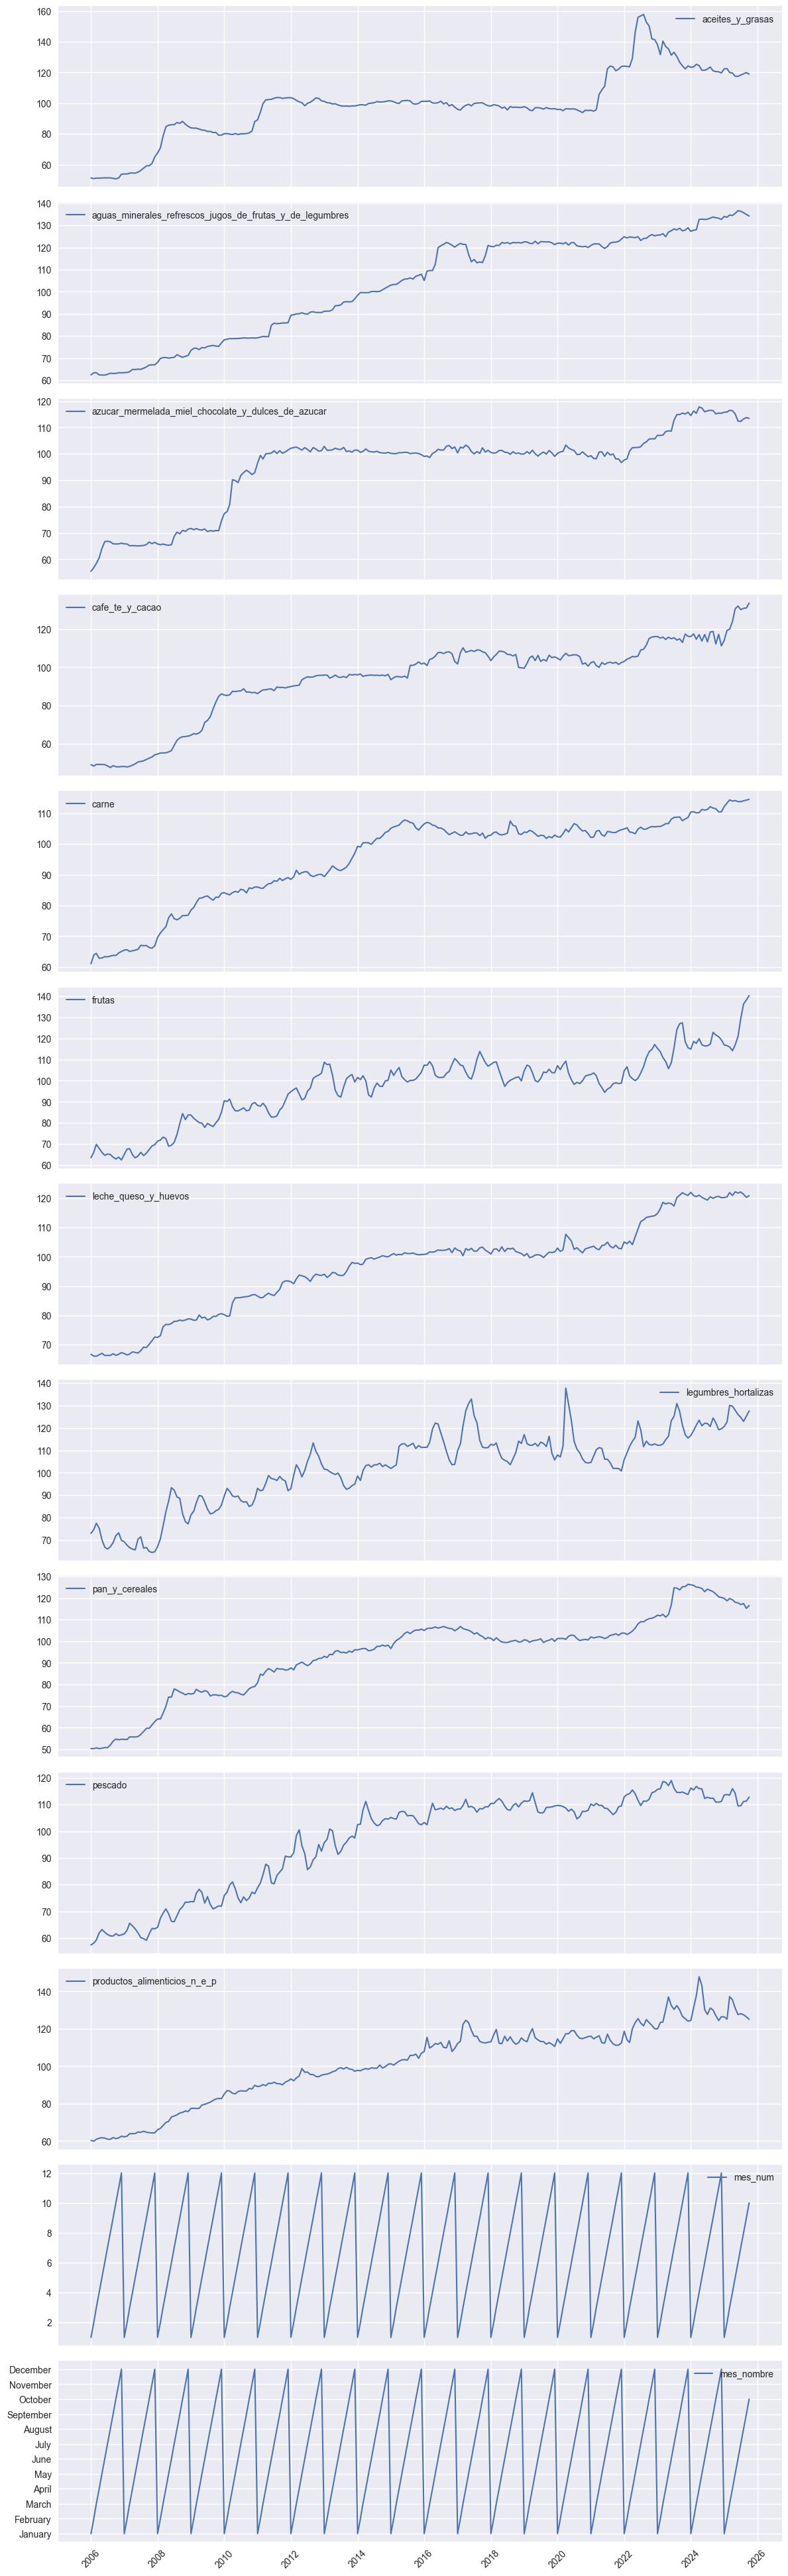

In [94]:
productos_cols = [col for col in data.columns if col != "ipc_alimentos_index" and "var" not in col]

fig, axes = plt.subplots(len(productos_cols), 1, figsize=(12,3*len(productos_cols)), sharex=True)


for ax, col in zip(axes, productos_cols):
    ax.plot(data.index, data[col], label=col, linewidth=1.5)
    ax.legend()
    ax.grid(True)

formato_anos(axes[-1], cada_n_anos=2)
plt.tight_layout()
plt.show()


# Evolución temporal del IPC de alimentos con subíndices

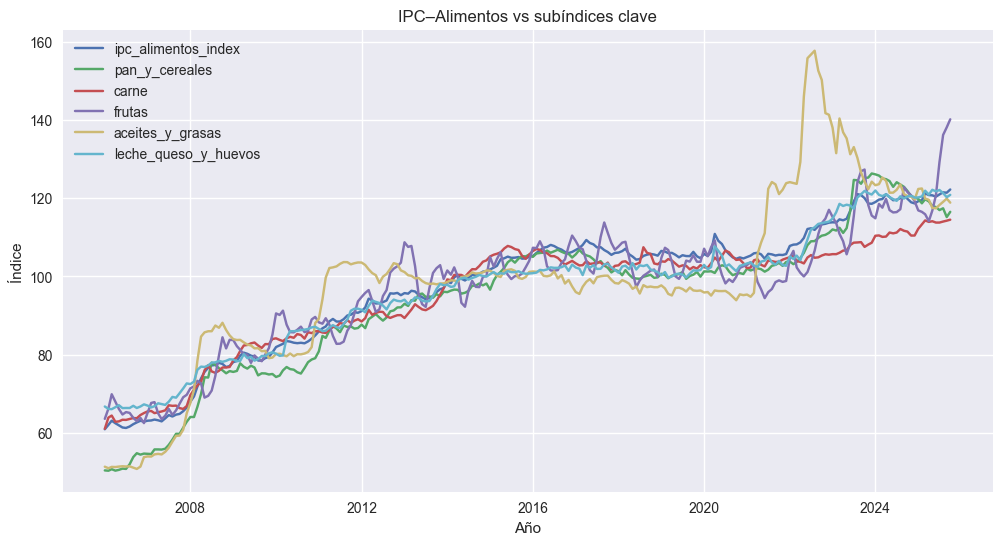

In [95]:
cols_clave = ["ipc_alimentos_index", "pan_y_cereales", "carne", "frutas", "aceites_y_grasas", "leche_queso_y_huevos"]

plt.figure(figsize=(12,6))
for col in cols_clave:
    plt.plot(data.index, data[col], label=col)

plt.title("IPC–Alimentos vs subíndices clave")
plt.xlabel("Año")
plt.ylabel("Índice")
plt.legend()
formato_anos(ax, cada_n_anos=2)
plt.grid(True)
plt.show()

#### Los grupos seleccionados representan los componentes más influyentes dentro de la dinámica del IPC de Alimentos.
#### Representan las correlaciones más altas con respecto al índice general. Importante en el gasto alimentario de los hogares, por lo que tienen efecto directo en la percepción y el costo de vida.

# Distribución y Detección de valores atípicos

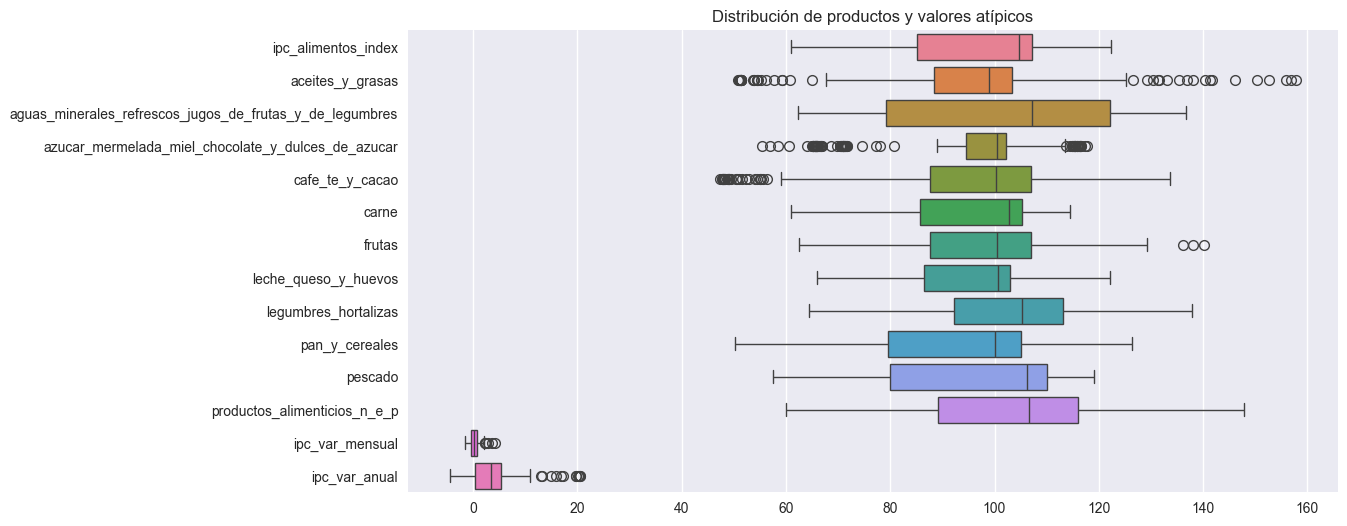

In [87]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data, orient='h')
plt.title("Distribución de productos y valores atípicos")
plt.show()


#### La mayoría de productos presentan distribuciones centradas entre los valore de 70 y 120 (Oscilación de precios en este rango).
#### Grupos de productos como aceites, y grasas, frutas, aguas y refrescos y producto alimenticios n.e.p tienen cajas más amplias y puntos atípicos. Altamente volátiles con presencia de episódios de aumentos abrutos en sus precios
#### Grupo como café es más sensible a choques externos, volatil con presencia de muchos outliers
#### Grupos como carne, leche–queso–huevos y pan y cereales muestran distribuciones más estables sin tantos outliers.
#### Variables de variación mensual y anual presentan cajas mucho más pequeñas y valores muy cercanos a cero, evidenciando que representan cambios relativos más que niveles absolutos, y que su distribución es completamente distinta al resto de los productos.

# Inflación mensual promedio del IPC de alimentos y su volatilidad

In [88]:
data["ipc_var_mensual"] = data["ipc_alimentos_index"].pct_change() * 100
var_mensual = data["ipc_var_mensual"].dropna()
promedio_mensual = var_mensual.mean()
volatilidad_mensual = var_mensual.std()
promedio_mensual, volatilidad_mensual
print(f"Tasa de crecimiento mensual promedio: {promedio_mensual:.3f}%")
print(f"Volatilidad (desviación estándar) mensual: {volatilidad_mensual:.3f}%")

Tasa de crecimiento mensual promedio: 0.298%
Volatilidad (desviación estándar) mensual: 0.850%


# Distribución de la inflación mensual

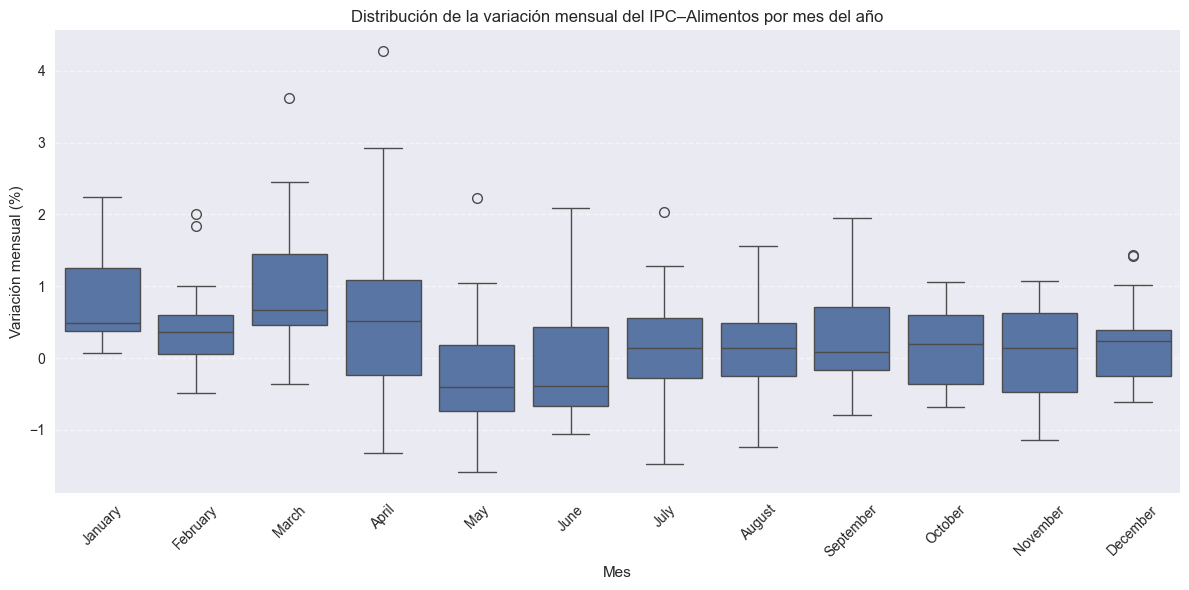

In [89]:
data.index = pd.to_datetime(data.index)
data["ipc_var_mensual"] = data["ipc_alimentos_index"].pct_change() * 100
data["mes_num"] = data.index.month
data["mes_nombre"] = data.index.month.map(lambda m: calendar.month_name[m])
df_box = data.dropna(subset=["ipc_var_mensual"])

plt.figure(figsize=(12,6))
sns.boxplot(x="mes_nombre", y="ipc_var_mensual", data=df_box, order=[
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])
plt.title("Distribución de la variación mensual del IPC–Alimentos por mes del año")
plt.xlabel("Mes")
plt.ylabel("Variación mensual (%)")
plt.xticks(rotation=45)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


#### La varación mensual del IPC de alimentos muestra una estacionalidad marcada. En meses como enenro, marzo y abril muestran medianas más altas y una mayor amplitud intercuartílica.
#### Este cambio puede ser por ajustes de inicio de año, efectos post-navideños o factores estacionales como cosechas y logística.
#### Meses como mayo, junio y julio registran medianas más bajas (cercado a negativo o cero). Son meses estables
#### Meses desde agosto a diciembre muestran unu comportamiento más estable con menos picos.
#### La inflación alimentaria no es uniforme a lo largo del año, responde a ciclos estacionales que concentran mayores presiones inflacionarias en el primer trimestre y parte del segundo.

# IPC Alimentos - Eventos macro relevantes

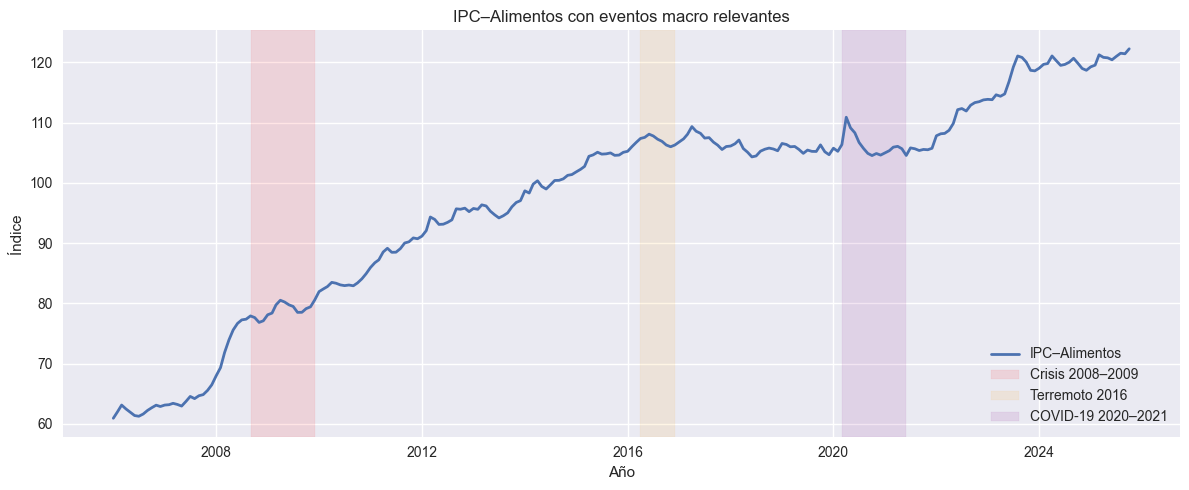

In [90]:
data.index = pd.to_datetime(data.index)
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(data.index, data["ipc_alimentos_index"], label="IPC–Alimentos", linewidth=2)

# Crisis financiera 2008–2009
ax.axvspan(pd.to_datetime("2008-09-01"), pd.to_datetime("2009-12-01"),
           color="red", alpha=0.1, label="Crisis 2008–2009")

# Terremoto 2016
ax.axvspan(pd.to_datetime("2016-04-01"), pd.to_datetime("2016-12-01"),
           color="orange", alpha=0.1, label="Terremoto 2016")

# Pandemia COVID-19
ax.axvspan(pd.to_datetime("2020-03-01"), pd.to_datetime("2021-06-01"),
           color="purple", alpha=0.1, label="COVID-19 2020–2021")

ax.set_title("IPC–Alimentos con eventos macro relevantes")
ax.set_xlabel("Año")
ax.set_ylabel("Índice")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

#### Durante la crísis financiara global de 2008-2009 se aprecia un incremento acelerado del IPC. Impacto significativo sobre los precios de alimentos en Ecuador (Encarecimiento de importacions, ajustes de los mercados de materias primas y presisones de costos)
#### En el terremoto de 2016 se ve una ligera alza del IPC. No exitió un impacto tan prolongado.
#### En pandemia de COVID-19 entre 2020-2021 muestra una inestabilidad moderada con un pico al inicio de este evento. A partir del fin de este periódo se evidencia un crecimiento marcado, alcanzando valores altos. (Rezago inflacionario acumulado)
#### Efectos globales post-pandemia y shocks de oferta.